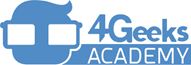

<h1><b>Data Science and Machine Learning</b></h1>
<h2><b>Clase 21</b>: Naive Bayes</h2>
<h3><b>Docente</b>: <a href="https://www.linkedin.com/in/danielablanco/">Daniela Blanco</a>

# Contenido

- [1. Naive Bayes](#naive_bayes)
- [2. Teorema de Bayes](#teorema)
- [3. Algoritmo Naive Bayes](#algoritmo)
- [4. Implementaciones](#implementaciones)
- [5. Hiperparámetros](#hiperparametros)
- [6. Ejemplo práctico](#ejemplo)
- [7. Links de interés](#links)


In [1]:
import pandas as pd
import numpy as np
import random

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.datasets import fetch_20newsgroups

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.model_selection import train_test_split

from sklearn.naive_bayes import GaussianNB
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import classification_report

import warnings
warnings.filterwarnings('ignore')

## 1. Naive Bayes <a name="naive_bayes"></a>

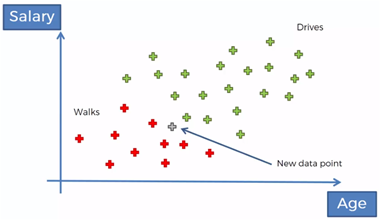

**Naive Bayes** es un algoritmo de clasificación basado en el teorema de Bayes, que es una técnica estadística que utiliza la probabilidad para hacer predicciones.

Este algoritmo es muy simple pero efectivo.

El nombre ingenuo (Naive) proviene del supuesto que las variables predictoras son independientes entre sí.

En otras palabras, que la presencia de una cierta característica en un conjunto de datos no está en absoluto relacionada con la presencia de cualquier otra característica.

Asume que cada característica contribuye de forma independiente a la probabilidad de pertenecer a una clase particular.

#### Ejemplo clasificador manzanas

- Una fruta puede ser considerada como una manzana si es roja, redonda y de alrededor de 7 cm de diámetro.

- Un clasificador ingenuo de Bayes considera que cada una de estas características contribuye de manera independiente a la probabilidad de que esta fruta sea una manzana, independientemente de la presencia o ausencia de las otras características.

## 2. Teorema de Bayes <a name="teorema"></a>

El teorema de Bayes es un concepto fundamental en probabilidad que nos permite actualizar nuestras creencias o probabilidades sobre un evento dadas nuevas evidencias.

La fórmula en la que se fundamenta este teorema es la siguiente:

$$
P(A|B) = \frac{P(B|A) \cdot P(A)}{P(B)}
$$

Donde:
- $P(A|B)$: Probabilidad de $A$ dado $B$.
- $P(B|A)$: Probabilidad de $B$ dado $A$.
- $P(A)$: Probabilidad de $A$.
- $P(B)$: Probabilidad de $B$.

### Ejemplo herramientas

Tenemos dos máquinas (m1 y m2) que fabrican la misma herramienta.

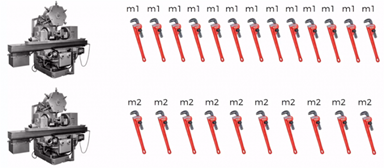

De todas las herramientas que fabrica cada una de las máquinas, algunas se producen con defectos (color negro).

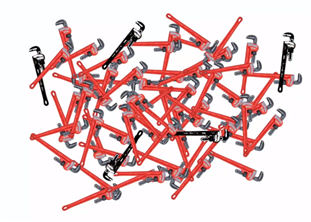

Si consideramos que la máquina 1 produce 30 llaves por hora y la máquina 2 produce 20 llaves por hora.

De todas las partes producidas se observa que el 1% están defectuosas y de todas las llaves defectuosas el 50% provienen de la máquina 1 y el 50% de la máquina 2.

**¿Cuál es la probabilidad de que una pieza defectuosa haya sido producida por la máquina 2?**

$P(M1)$ = 30/50 = 0.6

$P(M2)$ = 20/50 = 0.4

$P(Defecto)$ = 0.01

$P(M1 | Defecto)$ = 0.5

$P(M2 | Defecto)$ = 0.5

$$
P(Defecto|M2) = \frac{P(M2|Defecto) \cdot P(Defecto)}{P(M2)}
$$

$$
P(Defecto|M2) = \frac{0.5 \cdot 0.01}{0.4} = 0.0125
$$

La probabilidad de que una pieza defectuosa sea de la máquina 2 es del 1.25%.

## 3. Algoritmo Naive Bayes<a name="algoritmo"></a>

El algoritmo Naive Bayes calcula la probabilidad de que un dato pertenezca a una clase $C_k$, dado un conjunto de características ${x_1, x_2, ..., x_n}$.

Utilizando la fórmula de Bayes y suponiendo independencia entre las características (de ahí el término "naive"), se puede expresar así:

$$
P(C_k|X) = \frac{P(X|C_k) \cdot P(C_k)}{P(X)}
$$

Donde:

- $P(C_k|X)$: Probabilidad posterior de que el dato pertenezca a la clase $C_k$, dado el conjunto de características $X$.
- $P(X|C_k)$: Probabilidad de observar las características $X$ dado que el dato pertenece a la clase $C_k$.
- $P(C_k)$: Probabilidad previa de la clase $C_k$.
- $P(X)$: Probabilidad previa de las características $X$.


### Clasificación

Para clasificar un nuevo dato, el algoritmo:

1. Calcula $P(C_k|X)$ para cada clase $C_k$.
2. Asigna la clase con la mayor probabilidad posterior.

$$
\text{Clase Predicha} = \underset{C_k}{\text{argmax}} \; P(C_k|X)
$$

Esto significa que elegimos la clase con la probabilidad más alta.

### ¿Cómo se calcula $P(X|C_k)$?

Probabilidad de observar las características $X$ dado que el dato pertenece a la clase $C_k$.

Dado que las características de $𝑋$={$x_1$,$x_2$,...,$𝑥_𝑛$} son independientes entre sí:

$$
P(X \mid C_k) = P(x_1 \mid C_k) \cdot P(x_2 \mid C_k) \cdot ... \cdot P(x_n \mid C_k)
$$

Cada probabilidad $P(x_i​ ∣C_k)$ se calcula a partir de los datos de entrenamiento, dependiendo del tipo de características.

- Para características categóricas:

   Se calcula como la frecuencia relativa de $x_i$ en la clase $C_k$.

$$
     P(x_i \mid C_k) = \frac{\text{número de ocurrencias de } x_i \text{ en } C_k}{\text{total de datos en } C_k}
$$

- Para características continuas:

  Se asume una **distribución normal (Gaussiana)** para cada característica, y se calcula usando la función de densidad de probabilidad:
     
$$
  P(x_i \mid C_k) = \frac{1}{\sqrt{2\pi\sigma_k^2}} \exp\left(-\frac{(x_i - \mu_k)^2}{2\sigma_k^2}\right)
$$

  Donde:
     
$\mu_k$: Media de la característica $x_i$ para la clase $C_k$.
     
$\sigma_k$: Desviación estándar de la característica $x_i$ para la clase $C_k$.

### ¿Cómo se calcula $P(C_k)$?

Se calcula como la proporción de ocurrencias de esa clase en el conjunto de datos de entrenamiento.

Representa la probabilidad inicial de que una instancia pertenezca a una clase antes de considerar cualquier característica.

$$
     P(C_k) = \frac{\text{número de ocurrencias de } C_k}{\text{total de instancias en el entrenamiento} C_k}
$$

### ¿Cómo se calcula $P(X)$?

Es constante para todas las clases.

No afecta la comparación de probabilidades entre clases. Por lo tanto, el término se ignora durante la clasificación.

En otras palabras, el algoritmo se enfoca únicamente en el numerador:

$$
P(C_k|X) ∝ P(X|C_k) \cdot P(C_k)
$$

donde el símbolo $∝$ indica que $P(C_k​ ∣X)$ es "proporcional" al producto de $
P(X∣C_k$) y $P(C_k)$.

#### Ejemplo Spam

Queremos clasificar correos electrónicos como **Spam** o **No Spam** basado en si contienen las palabras "Oferta" y "Descuento".

| ID   | Oferta | Descuento | Spam |
|------|--------|-----------|------|
| 1    | Sí     | Sí        | Sí   |
| 2    | Sí     | No        | No   |
| 3    | No     | Sí        | No   |
| 4    | Sí     | Sí        | Sí   |
| 5    | No     | No        | No   |

¿Un correo con las características **"Oferta = Sí, Descuento = No"** es **Spam** o **No Spam**?

1. Calcular las probabilidades a priori:

  $$
  P(\text{Spam}) = \frac{\text{Número de correos Spam}}{\text{Número total de correos}} = \frac{2}{5} = 0.4
  $$

  $$
  P(\text{No Spam}) = \frac{\text{Número de correos No Spam}}{\text{Número total de correos}} = \frac{3}{5} = 0.6
  $$

2. Calcular las probabilidades condicionales:

  $$
  P(\text{Oferta = Sí} \mid \text{Spam}) = \frac{\text{Spam con Oferta Sí}}{\text{Total correos Spam}} = \frac{2}{2} = 1
  $$

  $$
  P(\text{Descuento = No} \mid \text{Spam}) = \frac{\text{Spam con Descuento  No}}{\text{Total correos Spam}} = \frac{0}{2} = 0
  $$

  $$
  P(\text{Oferta = Sí} \mid \text{No Spam}) = \frac{\text{No Spam con Oferta Sí}}{\text{Total correos No Spam}} = \frac{1}{3} \approx 0.33
  $$

  $$
  P(\text{Descuento = No} \mid \text{No Spam}) = \frac{\text{No Spam con Descuento No}}{\text{Total correos No Spam}} = \frac{2}{3} \approx 0.66
  $$

3. Aplicar la fórmula de Naive Bayes:

  $$
  P(\text{Spam} \mid \text{Datos}) \propto P(\text{Spam}) \cdot P(\text{Oferta = Sí} \mid \text{Spam}) \cdot P(\text{Descuento = No} \mid \text{Spam})
  $$

  $$
  P(\text{Spam} \mid \text{Datos}) \propto 0.4 \cdot 1 \cdot 0 = 0
  $$

  $$
  P(\text{No Spam} \mid \text{Datos}) \propto P(\text{No Spam}) \cdot P(\text{Oferta = Sí} \mid \text{No Spam}) \cdot P(\text{Descuento = No} \mid \text{No Spam})
  $$

  $$
  P(\text{No Spam} \mid \text{Datos}) \propto 0.6 \cdot 0.33 \cdot 0.66 \approx 0.13068
  $$

4. Clasificación final:

  $P(\text{Spam} \mid \text{Datos}) = 0$

  $P(\text{No Spam} \mid \text{Datos}) \approx 0.13068$

El correo se clasifica como **No Spam**, ya que tiene la probabilidad más alta.


## 4. Implementaciones <a name="implementaciones"></a>


En `scikit-learn` hay tres implementaciones de este modelo.

Se diferencian principalmente en el tipo de datos que pueden manejar y las suposiciones que hacen sobre la distribución de los datos.

|                |                      GaussianNB                      |                                    MultinomialNB                                   | BernoulliNB                                             |
|:--------------:|:----------------------------------------------------:|:----------------------------------------------------------------------------------:|---------------------------------------------------------|
| Tipo de datos  | Datos continuos.                                     | Datos discretos.                                                                   | Datos binarios.                                         |
|Distribuciones |Supone distribución normal. |Supone distribución multinomial.                          |Supone una distribución Bernoulli. |
| Uso común      | Clasificación con características numéricas.         | Clasificación con características que representan conteos. | Clasificación con características binarias.             |

Si tenemos características numéricas y categóricas para preservar la utilidad e idoneidad de este modelo se debe transformar las categóricas en numéricas utilizando técnicas de codificación.

## 5. Hiperparámetros <a name="hiperparametros"></a>

Algunos de sus hiperparámetros más importantes son:

**alpha**: Se utiliza para evitar probabilidades cero en características que no aparecen en el conjunto de entrenamiento. Un valor mayor agrega más suavizado (solo para `MultinomialNB` y `BernoulliNB`).

**fit_prior**: Indica si se deben aprender las probabilidades a priori de las clases a partir de los datos o si se deben usar probabilidades uniformes (solo para `MultinomialNB`).

**binarize**: Umbral para normalizar características. Si se proporciona un valor, las características se binarizan según ese umbral; de lo contrario, se asume que las características ya están binarizadas. Si no lo estuvieran y no se usa este hiperparámetro, el modelo puede no funcionar bien (solo para `BernoulliNB`).

## 6. Ejemplo práctico <a name="ejemplo"></a>

### Iris

In [2]:
X, y = load_iris(return_X_y = True, as_frame = True)

In [3]:
# split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [4]:
X_train.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
22,4.6,3.6,1.0,0.2
15,5.7,4.4,1.5,0.4
65,6.7,3.1,4.4,1.4
11,4.8,3.4,1.6,0.2
42,4.4,3.2,1.3,0.2


Siendo la clase `0` una `iris setosa`, la `1` una `iris versicolor` y la `2` una `iris virginica`.

In [5]:
y.unique()

array([0, 1, 2])

No es necesario que las variables predictoras estén normalizadas, ya que estos modelos están basados en el teorema de Bayes y hacen suposiciones específicas sobre la distribución de los datos, pero no están afectados directamente por la escala de las características.

In [6]:
# modelo
model = GaussianNB()

# entrenamiento
model.fit(X_train, y_train)

GaussianNB()

In [7]:
# predicción
y_pred_train = model.predict(X_train)

y_pred_test = model.predict(X_test)
y_pred_test

array([1, 0, 2, 1, 1, 0, 1, 2, 1, 1, 2, 0, 0, 0, 0, 1, 2, 1, 1, 2, 0, 2,
       0, 2, 2, 2, 2, 2, 0, 0])

In [10]:
X_test.shape

(30, 4)

In [8]:
# metricas
accuracy_test = accuracy_score(y_test, y_pred_test)
accuracy_train = accuracy_score(y_train, y_pred_train)

print("Accuracy Test: ", accuracy_test)
print("Accuracy Train: ", accuracy_train)

Accuracy Test:  1.0
Accuracy Train:  0.95


### Newsgroups

El dataset fetch_20newsgroups de `Scikit-learn` es un conjunto de datos popular para experimentos de clasificación de texto.

Contiene publicaciones de 20 diferentes grupos de noticias (newsgroups) de Usenet, organizadas en categorías temáticas como deportes, tecnología, política, ciencia, entre otras.

In [11]:
# datos
data = fetch_20newsgroups()

#categorias
text_categories = data.target_names

In [12]:
text_categories

['alt.atheism',
 'comp.graphics',
 'comp.os.ms-windows.misc',
 'comp.sys.ibm.pc.hardware',
 'comp.sys.mac.hardware',
 'comp.windows.x',
 'misc.forsale',
 'rec.autos',
 'rec.motorcycles',
 'rec.sport.baseball',
 'rec.sport.hockey',
 'sci.crypt',
 'sci.electronics',
 'sci.med',
 'sci.space',
 'soc.religion.christian',
 'talk.politics.guns',
 'talk.politics.mideast',
 'talk.politics.misc',
 'talk.religion.misc']

In [13]:
# Split
train_data = fetch_20newsgroups(subset="train", categories=text_categories)
test_data = fetch_20newsgroups(subset="test", categories=text_categories)

In [14]:
print("Clases únicas {}".format(len(text_categories)))
print("Datos train {} ".format(len(train_data.data)))
print("Datos test {}".format(len(test_data.data)))

Clases únicas 20
Datos train 11314 
Datos test 7532


In [15]:
print(test_data.data[3])

From: bakken@cs.arizona.edu (Dave Bakken)
Subject: Re: Saudi clergy condemns debut of human rights group!
Keywords: international, non-usa government, government, civil rights, 	social issues, politics
Organization: U of Arizona CS Dept, Tucson
Lines: 101

In article <benali.737307554@alcor> benali@alcor.concordia.ca ( ILYESS B. BDIRA ) writes:
>It looks like Ben Baz's mind and heart are also blind, not only his eyes.
>I used to respect him, today I lost the minimal amount of respect that
>I struggled to keep for him.
>To All Muslim netters: This is the same guy who gave a "Fatwah" that
>Saudi Arabia can be used by the United Ststes to attack Iraq . 

They were attacking the Iraqis to drive them out of Kuwait,
a country whose citizens have close blood and business ties
to Saudi citizens.  And me thinks if the US had not helped out
the Iraqis would have swallowed Saudi Arabia, too (or at 
least the eastern oilfields).  And no Muslim country was doing
much of anything to help liberate Ku

In [16]:
print(test_data.data[3])

From: bakken@cs.arizona.edu (Dave Bakken)
Subject: Re: Saudi clergy condemns debut of human rights group!
Keywords: international, non-usa government, government, civil rights, 	social issues, politics
Organization: U of Arizona CS Dept, Tucson
Lines: 101

In article <benali.737307554@alcor> benali@alcor.concordia.ca ( ILYESS B. BDIRA ) writes:
>It looks like Ben Baz's mind and heart are also blind, not only his eyes.
>I used to respect him, today I lost the minimal amount of respect that
>I struggled to keep for him.
>To All Muslim netters: This is the same guy who gave a "Fatwah" that
>Saudi Arabia can be used by the United Ststes to attack Iraq . 

They were attacking the Iraqis to drive them out of Kuwait,
a country whose citizens have close blood and business ties
to Saudi citizens.  And me thinks if the US had not helped out
the Iraqis would have swallowed Saudi Arabia, too (or at 
least the eastern oilfields).  And no Muslim country was doing
much of anything to help liberate Ku

In [17]:
# Vectorización con TfidfVectorizer
vectorizer = TfidfVectorizer()

X_train_tfidf = vectorizer.fit_transform(train_data.data)
X_test_tfidf = vectorizer.transform(test_data.data)

In [19]:
# Entrenamiento del clasificador
model = MultinomialNB()

model.fit(X_train_tfidf, train_data.target)

MultinomialNB()

In [20]:
# predicción
y_pred_train = model.predict(X_train_tfidf)
y_pred_test = model.predict(X_test_tfidf)

In [21]:
# metricas
accuracy_test = accuracy_score(test_data.target, y_pred_test)
accuracy_train = accuracy_score(train_data.target, y_pred_train)

print("Accuracy Test: ", accuracy_test)
print("Accuracy Train: ", accuracy_train)

Accuracy Test:  0.7738980350504514
Accuracy Train:  0.9326498143892522


# Probando el modelo

In [22]:
# Selección de categorías acotada para ejemplifizar
categories = ['sci.space', 'rec.sport.hockey', 'talk.politics.mideast']

# Carga de datos
newsgroups = fetch_20newsgroups(subset='all', categories=categories)
X = newsgroups.data
y = newsgroups.target
target_names = newsgroups.target_names

# División entrenamiento/prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Vectorización TF-IDF
vectorizer = TfidfVectorizer()
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# Entrenamiento del modelo
model = MultinomialNB()
model.fit(X_train_tfidf, y_train)

# Predicción
y_pred = model.predict(X_test_tfidf)

# Separar índices de clasificaciones correctas e incorrectas
correctos = [i for i in range(len(y_test)) if y_pred[i] == y_test[i]]
incorrectos = [i for i in range(len(y_test)) if y_pred[i] != y_test[i]]

# Elegir un ejemplo al azar de cada grupo
idx_correcto = random.choice(correctos)
idx_incorrecto = random.choice(incorrectos)

In [24]:
# Mostrar ejemplo correcto
print("✅ Clasificación CORRECTA:")
print("Texto:", X_test[idx_correcto][:1500], "...")
print("Etiqueta real:", target_names[y_test[idx_correcto]])
print("Etiqueta predicha:", target_names[y_pred[idx_correcto]])

✅ Clasificación CORRECTA:
Texto: From: "Carl D. Lovejoy" <cl3d+@andrew.cmu.edu>
Subject: Re: Don Cherry-New Pens Annoucer?
Organization: Junior, Materials Science and Engineering, Carnegie Mellon, Pittsburgh, PA
Lines: 22
NNTP-Posting-Host: po2.andrew.cmu.edu
In-Reply-To: <C5wIuy.D88.1@cs.cmu.edu>

>KBL and the Penguins have just inked a new deal, giving KBL all 
>TV and radio rights to Pens games.  Plans are that KBL would like
>to have an entire night of hockey, starting with a 7:00 pre-game
>show and running to a post game show that would sign off about 11:00
>(depending upon length of the game).
> 
>Don Cherry announcing Penguins games.  Yeah, and (to quote Pgh's
>goofy mayor) I'm the Queen of Sheba.
> 
>Lori
>Contact for the Penguins
>lli+@cs.cmu.edu

    Well I was watching Hockey Hotline last night and Stan said that the
station (KBL) had been recieving calls all day concerning this subject. 
And the verdict was that almost exclusively NOBODY wanted that load
mouth, know it all 

In [25]:
# Mostrar ejemplo incorrecto
print("\n❌ Clasificación INCORRECTA:")
print("Texto:", X_test[idx_incorrecto][:1500], "...")
print("Etiqueta real:", target_names[y_test[idx_incorrecto]])
print("Etiqueta predicha:", target_names[y_pred[idx_incorrecto]])


❌ Clasificación INCORRECTA:
Texto: From: bobo@thejester.cray.com (Bob Kierski)
Subject: Re: Philosophy Quest.  How Boldly?
Originator: bobo@thejester.cray.com
Lines: 47
Nntp-Posting-Host: thejester
Organization: Cray Research, Inc.


In article <C6Assy.Ao9@fs7.ece.cmu.edu>, loss@fs7.ECE.CMU.EDU (Doug Loss) writes:

>    Analog SF magazine did an article on a similar subject quite a few
> years ago.  The question was, if an alien spacecraft landed in
> Washington, D.C., what was the proper organization to deal with it: The
> State Department (alien ambassadors), the Defense Department (alien
> invaders), the Immigration and Naturalization Service (illegal aliens),
> the Department of the Interior (new non-human species), etc.  It was
> very much a question of our perception of the aliens, not of anything
> intrinsic in their nature.  The bibliography for the article cited a
> philosophical paper (the name and author of which I sadly forget; I
> believe the author was Italian) on what c

## 6. Links de interés <a name="links"></a>

- [Manual con Scikit-learn para Naive Bayes](https://scikit-learn.org/stable/modules/naive_bayes.html)
- [Tutorial de clasificación Naive Bayes con Scikit-learn](https://www.datacamp.com/es/tutorial/naive-bayes-scikit-learn)
- [Naive Bayes, Clearly Explained](https://www.youtube.com/watch?v=O2L2Uv9pdDA)